# <center>**Source Model**<center>

**Libraries**

In [1]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

import mbloodmoon as bm
from mbloodmoon.mask import _convolution_kernel_psfy, psfy_wfm
import mbloodmoon.iros_management as iros

from _IROS_support import _handle_dirpaths
from temp_camera import CodedMaskCamera, codedmask


def plot_sequence(
    input_sequence: list,
    title: list[str],
    label: list = None,
    x: list = None,
    xlabel: list[str] = None,
    ylabel: list[str] = None,
    color: list[tuple[str, str]] = None,
    style: list[str] = None,
    offsetx: list[tuple[float, float]] = None,
    offsety: list[tuple[float, float]] = None,
    save_to: str = None,
) -> None:

    def _handle_subplots(nplots, spacing=0.27):
        """Creates and configures subplots."""
        size = 6
        fig_size = (size * nplots + 1, size) if nplots > 1 else (size, size)
        fig, axes = plt.subplots(1, nplots, figsize=fig_size)
        fig.tight_layout()
        fig.subplots_adjust(wspace=spacing * 5 / size)
        return fig, (axes if nplots > 1 else [axes])

    def _set_labels(ax, xlabel, ylabel, title):
        """Configures labels and titles."""
        ax.set_xlabel(xlabel or "", fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel or "", fontsize=12, fontweight='bold')
        ax.set_title(title, fontsize=14, pad=8, fontweight='bold')

    def _set_ticks(ax):
        """Configures grid and tick properties."""
        ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2, alpha=0.70)
        ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')

    nplots = len(input_sequence)
    x = x or [None] * nplots
    label = label or [None] * nplots
    xlabel = xlabel or [None] * nplots
    ylabel = ylabel or [None] * nplots
    color = color or [('OrangeRed', 'r')] * nplots
    style = style or ['bar'] * nplots
    offsetx = offsetx or [(None, None)] * nplots
    offsety = offsety or [(None, None)] * nplots

    fig, axes = _handle_subplots(nplots)
    for i, ax in enumerate(axes):
        x_values = x[i] if x[i] is not None else np.arange(len(input_sequence[i]))

        if isinstance(input_sequence[i], tuple):
            for idx in range(len(input_sequence[i])):
                fcolor, ecolor = color[i][idx]
                #ax.bar(x_values, input_sequence[i][idx], width=1, facecolor=fcolor,
                #       edgecolor=ecolor, linewidth=1, alpha=0.50, label=label[i][idx])
                ax.plot(x_values, input_sequence[i][idx], c=ecolor, alpha=0.75, label=label[i][idx])
                #ax.scatter(x_values, input_sequence[i][idx], facecolor=fcolor, edgecolors=ecolor,
                #           s=30, alpha=0.8, linewidths=1.5, label=label[i][idx])
        else:
            fcolor, ecolor = color[i]
            if style[i] == 'scatter':
                ax.plot(x_values, input_sequence[i], c=fcolor, alpha=0.75)
                #ax.scatter(x_values, input_sequence[i], facecolor=fcolor, edgecolors=ecolor,
                #           s=50, alpha=0.8, linewidths=1.5, label=label[i])
            else:
                ax.bar(x_values, input_sequence[i], width=1, facecolor=fcolor,
                       edgecolor=ecolor, linewidth=1, alpha=0.70)

        ax.set_xlim(offsetx[i][0], offsetx[i][1])
        ax.set_ylim(offsety[i][0], offsety[i][1])
        _set_labels(ax, xlabel[i], ylabel[i], title[i])
        _set_ticks(ax)
        if label[i] is not None: ax.legend(loc='best')
    
    if save_to is not None: plt.savefig(save_to)
    plt.show()



def enhance_slices(
    sky: list[np.array],
    label: list,
    pos: tuple[int],
    crp: tuple[int] = (40, 40),
    source: str = None,
    cameraID: str = None,
    offsety_first: list[tuple[float, float]] = None,
    offsety_second: list[tuple[float, float]] = None,
    save_to_first: str = None,
    save_to_second: str = None,
) -> None:
    
    sky_A, sky_B = sky
    cropped_A = iros.crop(sky_A, pos, crp)
    xslice_A, yslice_A = cropped_A[crp[0], :], cropped_A[:, crp[1]]
    cropped_B = iros.crop(sky_B, pos, crp)
    xslice_B, yslice_B = cropped_B[crp[0], :], cropped_B[:, crp[1]]

    plot_sequence(
        input_sequence=[(xslice_A, xslice_B), (yslice_A, yslice_B)],
        title=[
            f"{source.upper() if source else "Source"} {ax}-axis Slice - {cameraID.upper() if cameraID else ""}"
            for ax in ("X", "Y")
        ],
        label=label,
        x=[np.arange(len(s)) - len(s) // 2 for s in (xslice_A, yslice_A)],
        xlabel=["x", "y"],
        ylabel=["counts", "counts"],
        color=[(('white', 'r'), ('white', 'DodgerBlue'))] * 2,
        offsety=offsety_first,
        save_to=save_to_first,
    )
    plot_sequence(
        input_sequence=[(xslice_A - xslice_B), (yslice_A - yslice_B)],
        title=[
            f"{source.upper() if source else "Source"} {ax}-axis Slice Residues - {cameraID.upper() if cameraID else ""}"
            for ax in ("X", "Y")
        ],
        x=[np.arange(len(s)) - len(s) // 2 for s in (xslice_A, yslice_A)],
        xlabel=["x", "y"],
        ylabel=["counts", "counts"],
        style=["scatter"] * 2,
        offsety=offsety_second,
        save_to=save_to_second,
    )

**PSFY Kernel**

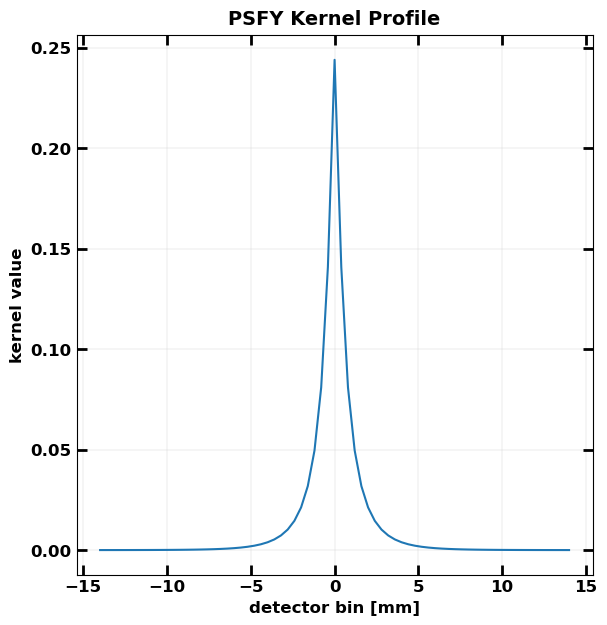

(array([-14. , -13.6, -13.2, -12.8, -12.4, -12. , -11.6, -11.2, -10.8,
        -10.4]),
 array([10.4, 10.8, 11.2, 11.6, 12. , 12.4, 12.8, 13.2, 13.6, 14. ]))

In [2]:
def _convolution_kernel_psfy(camera: CodedMaskCamera) -> npt.NDArray:
    """
    Returns PSF convolution kernel.
    At present, it ignores the `x` direction, since PSF characteristic lenght is much shorter
    than typical bin size, even at moderately large upscales.

    Args:
        camera: a CodedMaskCamera object.

    Returns:
        A column array convolution kernel.
    """
    # we take a whole slit to have a good kernel spatial extension
    slit = camera.mdl["slit_deltay"]
    # to define the kernel, we only need an array with the same binning step
    num = int(2 * slit * camera.upscale_f.y / camera.mdl["mask_deltay"]) + 1
    bins = np.linspace(-slit, slit, num)
    kernel = psfy_wfm(bins).reshape(len(bins), -1)
    kernel = kernel / np.sum(kernel)
    return kernel


mask_FITS = "wfm_mask.fits"
mask_path = "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/" + mask_FITS
#mask_path = "/mnt/d/PhD_AASS/Coding/Images_fits/" + mask_FITS
cam = codedmask(mask_path, upscale_y=1)

kernel = _convolution_kernel_psfy(cam)

slit = cam.mdl["slit_deltay"]
num = int(2 * slit * cam.upscale_f.y / cam.mdl["mask_deltay"]) + 1
bins = np.linspace(-slit, slit, num)
assert (abs(bins[1] - bins[0]) - cam.mdl["mask_deltay"] / cam.upscale_f.y) < 1e-10


fig, ax = plt.subplots(1, 1, figsize=(6, 6))
fig.tight_layout()
ax.plot(bins, kernel)
ax.set_xlabel("detector bin [mm]", fontsize=12, fontweight='bold')
ax.set_ylabel("kernel value", fontsize=12, fontweight='bold')
ax.set_title("PSFY Kernel Profile", fontsize=14, pad=8, fontweight='bold')
ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.3)
ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
plt.show()

bins[:10], bins[-10:]

<br>

**Setup**

In [3]:
mask_FITS = "wfm_mask.fits"

#skyfield = "GalacticCenter"
#data_FITS = "20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb"
#data_FITS = "20250320_galctr_rxte_sax_2-50keV_1ks_sources_cxb_infmaskdet"
#data_FITS = "20250131_galctr_rxte_sax_2-30keV_1ks_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_realmask_infdet_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_opaquemask_realdet_sources_cxb"
#data_FITS = "20250430_galctr_rxte_sax_2-50keV_1ks_thinmask_realdet_sources_cxb"


skyfield = "Crab"
data_FITS = "20250227_crab_cxb_2-50keV_1ks"


N_TEST = "test_PSFY_kernel_centered_upx5upy5"

UPX, UPY = 5, 5

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    test_name=N_TEST,
)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = "reconstructed"

filepaths = bm.simulation_files(simul_data)
energy_range = None
coords = None


wfm = codedmask(mask_path, UPX, UPY)
sdlA = bm.simulation(filepaths[cam_a][dataset], energy_range=energy_range, coords=coords)
sdlB = bm.simulation(filepaths[cam_b][dataset], energy_range=energy_range, coords=coords)

catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])

In [4]:
mask_path, simul_data, save_path

('/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/wfm_mask.fits',
 '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/Crab/20250227_crab_cxb_2-50keV_1ks/',
 '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Outputs/OutCrab/20250227_crab_cxb_2-50keV_1ks/test_PSFY_kernel_centered_upx5upy5/')

In [5]:
database_name = save_path + f"IROS_sources_database_TEST_{N_TEST}.fits"
database = iros.load_iros_data(database_name)

# Loading data...
# Loading completed!


- IROS sky residues

In [6]:
res_sky_camA, _ = iros.load_sky(save_path + f"skyRES_IROS_CAM1A_TEST_{N_TEST}.fits")
res_sky_camB, _ = iros.load_sky(save_path + f"skyRES_IROS_CAM1B_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


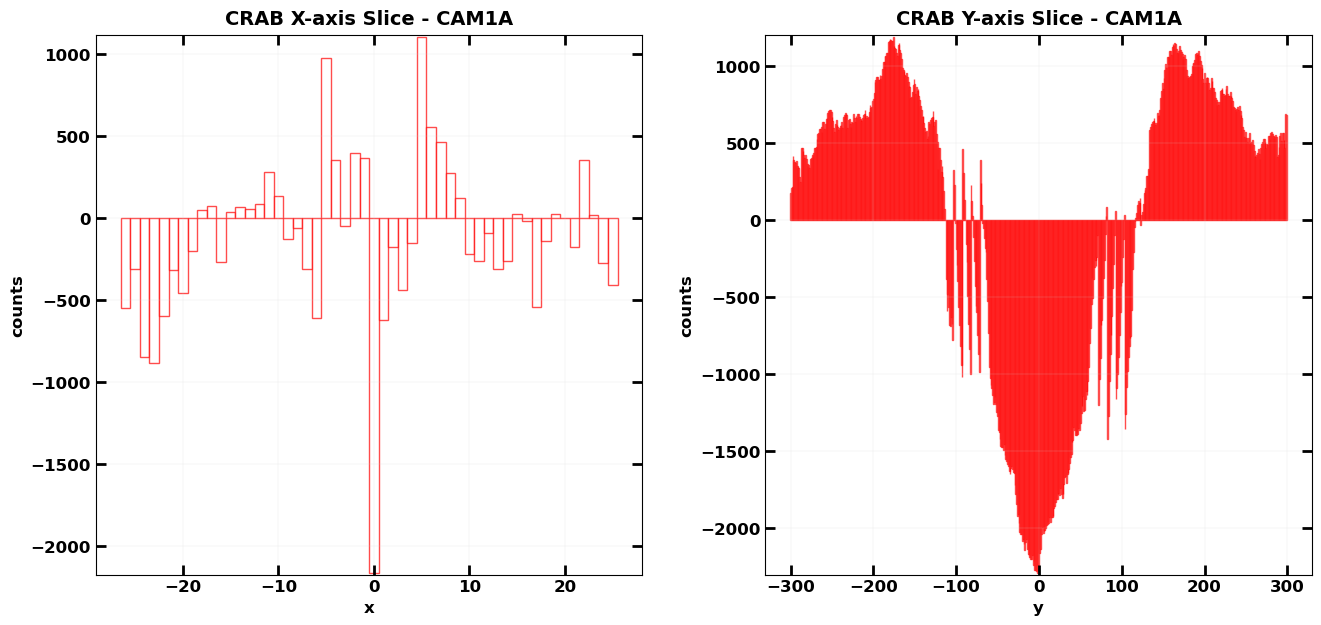

In [7]:
# CAM1A
_to = 1

for source, y, x in zip(
    database[cam_a]["catalog_name"]["data"][:_to],
    database[cam_a]["y"]["data"][:_to],
    database[cam_a]["x"]["data"][:_to],
):
    iros.enhance_slices(
        sky=res_sky_camA,
        pos=(y, x),
        crp=(int(50 * (1 + UPY)), int(10 * (1 + UPX / 3))),
        source=source,
        cameraID=cam_a,
    )

## CAM1B
#_to = 1
#
#for source, y, x in zip(
#    database[cam_b]["catalog_name"]["data"][:_to],
#    database[cam_b]["y"]["data"][:_to],
#    database[cam_b]["x"]["data"][:_to],
#):
#    iros.enhance_slices(
#        sky=res_sky_camB,
#        pos=(y, x),
#        crp=(int(50 * (1 + UPY)), int(10 * (1 + UPX / 3))),
#        source=source,
#        cameraID=cam_b,
#    )

- IROS reconstructed sky

In [8]:
simul_sky_camA, _ = iros.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
sky_camA, _ = iros.load_sky(save_path + f"OUTsky_IROS_CAM1A_TEST_{N_TEST}.fits")

simul_sky_camB, _ = iros.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
sky_camB, _ = iros.load_sky(save_path + f"OUTsky_IROS_CAM1B_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


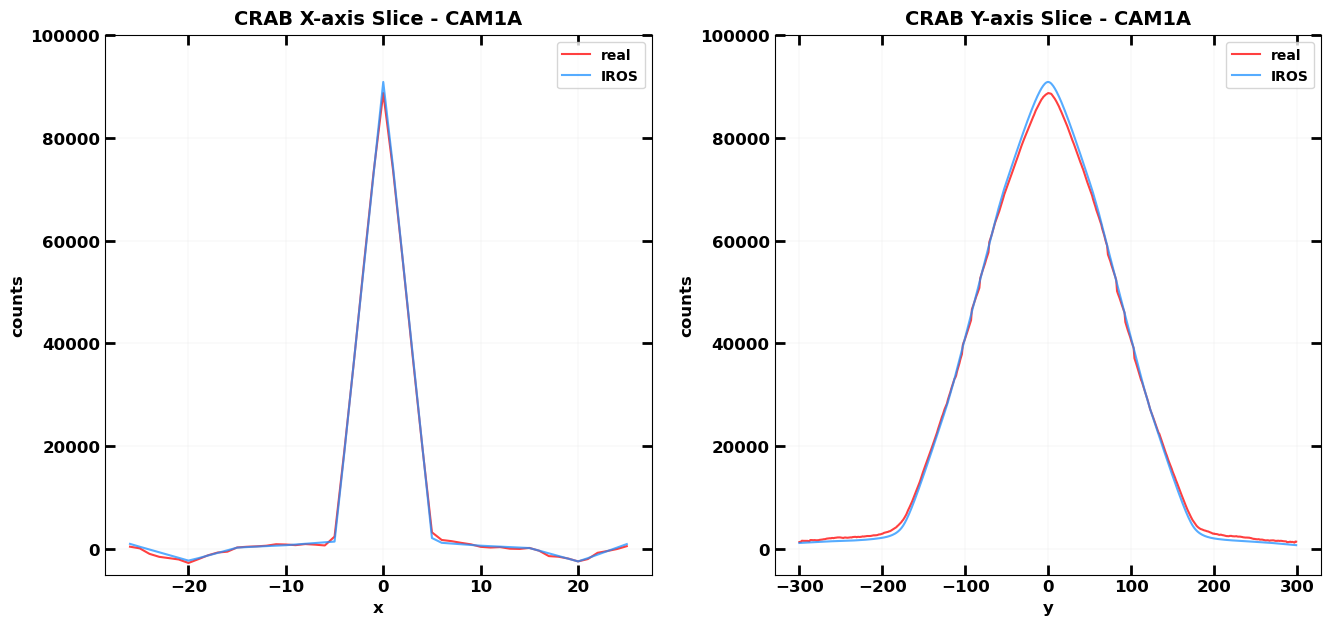

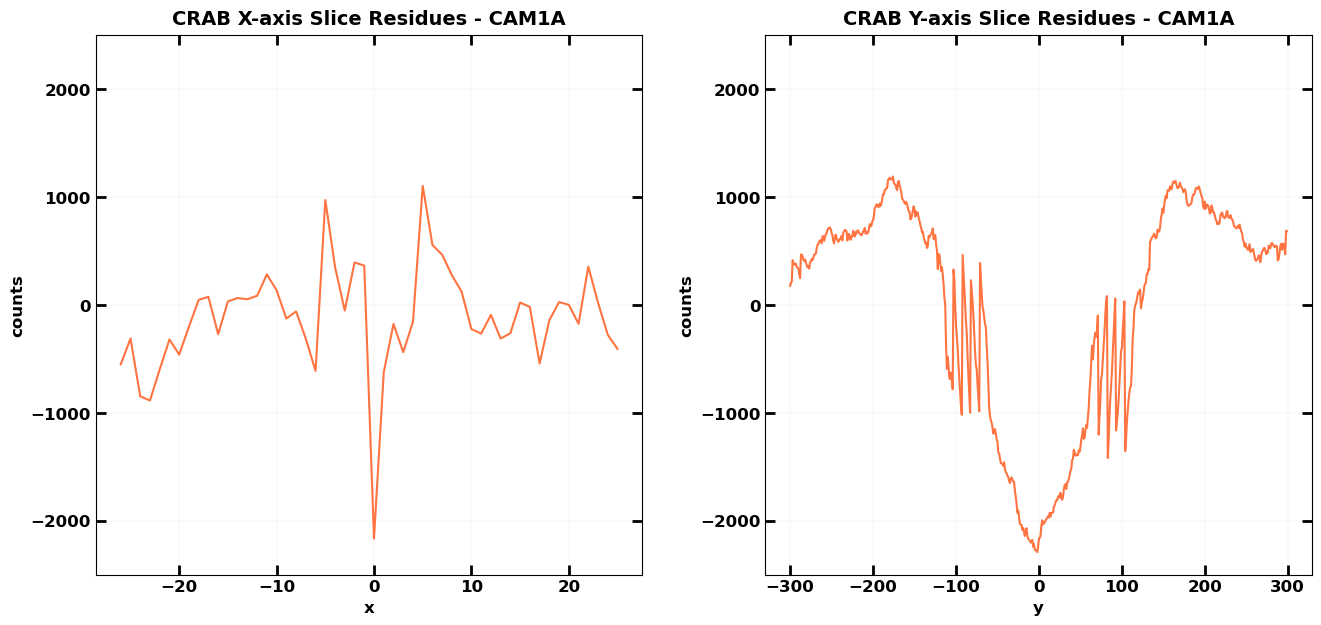

In [9]:
upx, upy = wfm.upscale_f
crp = (int(50 * (1 + upy)), int(10 * (1 + upx / 3)))
_to = 1

for source, y, x in zip(
    database[cam_a]["catalog_name"]["data"][:_to],
    database[cam_a]["y"]["data"][:_to],
    database[cam_a]["x"]["data"][:_to],
):
    enhance_slices(
        sky=[simul_sky_camA, sky_camA],
        label=[("real", "IROS")] * 2,
        pos=(y, x),
        crp=crp,
        source=source,
        cameraID=cam_a,
        offsety_first=[(-5000, 100000)] * 2,
        offsety_second=[(-2500, 2500)] * 2,
        #save_to_first=save_path + "../models.png",
        #save_to_second=save_path + "../res.png",
    )


## CAM1B
#_to = 1
#
#for source, y, x in zip(
#    database[cam_b]["catalog_name"]["data"][:_to],
#    database[cam_b]["y"]["data"][:_to],
#    database[cam_b]["x"]["data"][:_to],
#):
#    enhance_slices(
#        sky=[simul_sky_camB, sky_camB],
#        label=[("real", "IROS")] * 2,
#        pos=(y, x),
#        crp=crp,
#        source=source,
#        cameraID=cam_b,
#        offsety_first=[(-5000, 95000)] * 2,
#        offsety_second=[(-2500, 2000)] * 2,
#    )